<a href="https://colab.research.google.com/github/Kamindumenula/SE4050-Household-Waste-Classification-System/blob/main/mobilenetV2/mobileV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!git clone https://github.com/Kamindumenula/SE4050-Household-Waste-Classification-System.git
!unzip -q -o /content/SE4050-Household-Waste-Classification-System/dataset/archive.zip -d /content/

DATASET_PATH = "/content/dataset-resized"

fatal: destination path 'SE4050-Household-Waste-Classification-System' already exists and is not an empty directory.


In [6]:
import os

print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))
print("Contents:", os.listdir(DATASET_PATH))

Dataset path: /content/dataset-resized
Exists: True
Contents: ['paper', 'cardboard', 'glass', 'trash', 'plastic', 'metal']


In [7]:
import os

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:3]:
        print(f"{indent}    {file}")

dataset-resized/
    paper/
        paper578.jpg
        paper80.jpg
        paper377.jpg
    cardboard/
        cardboard133.jpg
        cardboard266.jpg
        cardboard398.jpg
    glass/
        glass101.jpg
        glass304.jpg
        glass91.jpg
    trash/
        trash101.jpg
        trash92.jpg
        trash79.jpg
    plastic/
        plastic20.jpg
        plastic352.jpg
        plastic212.jpg
    metal/
        metal240.jpg
        metal303.jpg
        metal295.jpg


In [8]:
import os

class_counts = {}

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts[class_name] = count

print("Images per class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal images:", sum(class_counts.values()))

Images per class:
paper: 594
cardboard: 403
glass: 501
trash: 137
plastic: 482
metal: 410

Total images: 2527


In [9]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


#DOWNLOAD & EXTRACT DATASET

if not os.path.exists("SE4050-Household-Waste-Classification-System"):
    !git clone https://github.com/Kamindumenula/SE4050-Household-Waste-Classification-System.git

DATASET_DIR = "/content/dataset-resized"
if not os.path.exists(DATASET_DIR):
    !unzip -q -o SE4050-Household-Waste-Classification-System/dataset/archive.zip -d /content/


# LOAD & SPLIT (80% TRAIN, 10% VAL, 10% TEST)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load 80% for training
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load 20% held-out
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 20% into 10% val and 10% test
val_size = int(len(val_test_ds) * 0.5)
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

# APPLY COMMON DATA AUGMENTATION (ONLY TO TRAIN DATASET!)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # Flips left/right
    layers.RandomRotation(0.15),      # Rotates ±15%
    layers.RandomZoom(0.15),          # Zooms in/out ±15%
    layers.RandomContrast(0.1),       # Slight lighting change
], name="common_data_augmentation")

# We apply augmentation directly to train_ds:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


# SPEED OPTIMIZATION (CACHE & PREFETCH)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

classes = sorted(os.listdir(DATASET_DIR))
print(f"Setup Complete!")
print(f"Classes ({len(classes)}): {classes}")
print(f"Batches -> Train: {len(train_ds)} (Augmented) | Val: {len(val_ds)} | Test: {len(test_ds)}")

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Setup Complete!
Classes (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Batches -> Train: 64 (Augmented) | Val: 8 | Test: 8


# MobileNetV2 Model

## 1. MobileNetV2 Architecture

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras import layers
from tensorflow import keras

In [11]:
NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)
print("Classes:", classes)

Number of classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [12]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 backbone created successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 backbone created successfully.


In [13]:
inputs = keras.Input(shape=(224, 224, 3))

# MobileNetV2-specific preprocessing
x = preprocess_input(inputs)

# Pretrained MobileNetV2 backbone
x = base_model(x, training=False)

# Convert feature maps to a feature vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.2)(x)

# 6 waste classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

mobilenetv2_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Waste_Classifier"
)

print("MobileNetV2 model created successfully.")

MobileNetV2 model created successfully.


In [14]:
mobilenetv2_model.summary()

Model: "MobileNetV2_Waste_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
mobilenetv2_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [16]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [17]:
EPOCHS = 15

history = mobilenetv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.5366 - loss: 1.2087 - val_accuracy: 0.7383 - val_loss: 0.7652 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7235 - loss: 0.7224 - val_accuracy: 0.7656 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7789 - loss: 0.6010 - val_accuracy: 0.7852 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7977 - loss: 0.5423 - val_accuracy: 0.7891 - val_loss: 0.5703 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8165 - loss: 0.4940 - val_accuracy: 0.8125 - val_loss: 0.5219 - learning_rate: 0.0010
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8225 - loss: 0.4789 - val_accuracy: 0.8047 - val_loss: 0.5414 - learning_rate: 0.0010
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.8343 - loss: 0.4522 - val_acc

In [18]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "mobilenetv2_baseline_history.csv",
    index=False
)

print("Baseline training history saved.")

Baseline training history saved.


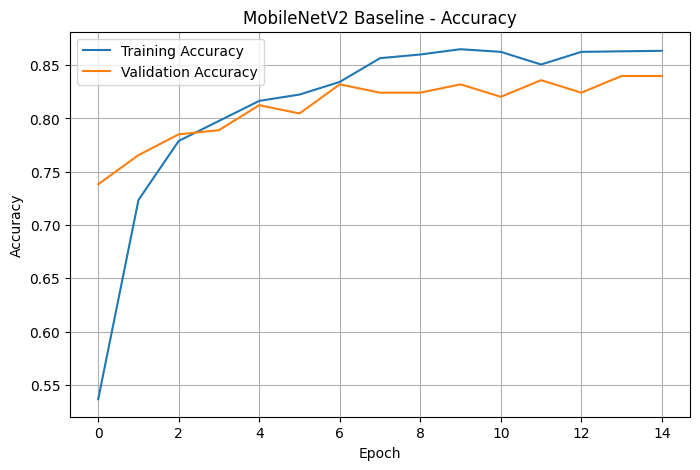

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Baseline - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

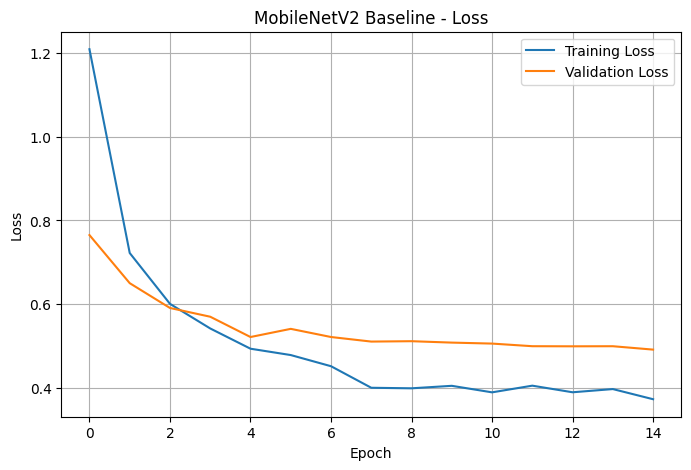

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Baseline - Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
mobilenetv2_model.save(
    "mobilenetv2_baseline.keras"
)

print("Baseline MobileNetV2 model saved.")

Baseline MobileNetV2 model saved.
